In [1]:
import spacy

In [2]:
# Cargar modelo en español
try:
    nlp = spacy.load("es_core_news_sm")
except OSError:
    print("Descargando modelo...")
    from spacy.cli import download
    download("es_core_news_sm")
    nlp = spacy.load("es_core_news_sm")

In [3]:
# Entrada de texto
with open("el_viejo_y_el_mar.txt", "r", encoding="utf-8") as f:
    texto_el_viejo_y_el_mar = f.read()

print(f"Texto cargado con éxito. Longitud: {len(texto_el_viejo_y_el_mar)} caracteres.")

Texto cargado con éxito. Longitud: 139981 caracteres.


In [4]:
# TOKENIZACIÓN
# Spacy procesa el texto y crea el objeto 'doc' lleno de metadatos
doc = nlp(texto_el_viejo_y_el_mar)

In [5]:
# Mostrar los primeros 15 tokens para entender cómo "ve" la máquina el texto
print(f"--- 1. Tokenización (Total tokens: {len(doc)}) ---")
print([token.text for token in doc][:20])

--- 1. Tokenización (Total tokens: 32358) ---
['El', 'Viejo', 'y', 'el', 'Mar', '\n', 'Por', '\n', 'Ernest', 'Hemingway', '\n\n\n', '---', 'FIN', 'DE', 'PÁGINA', '---', '\n\n', 'Era', 'un', 'viejo']


In [6]:
# FILTRADO DE STOP WORDS
# Separammos lo que aporta valor semántico del "pegamento" gramatical

tokens_relevantes = []
tokens_ruido = []

for token in doc:
    # Filtramos si es stop word o si es puntuación
    if not token.is_stop and not token.is_punct and token.text.strip():
        tokens_relevantes.append(token.text)
    elif token.is_stop:
        tokens_ruido.append(token.text)

print(f"\n--- 2. Filtrado de Stop Words ---")
print(f"Palabras eliminadas (Ruido): {tokens_ruido[:10]}...")
print(f"Palabras conservadas (Contenido): {tokens_relevantes[:10]}...")
print(f"Reducción de tamaño: de {len(doc)} a {len(tokens_relevantes)} tokens.")


--- 2. Filtrado de Stop Words ---
Palabras eliminadas (Ruido): ['El', 'y', 'el', 'Por', 'FIN', 'DE', 'Era', 'un', 'que', 'solo']...
Palabras conservadas (Contenido): ['Viejo', 'Mar', 'Ernest', 'Hemingway', 'PÁGINA', 'viejo', 'pescaba', 'bote', 'corriente', 'Golfo']...
Reducción de tamaño: de 32358 a 10045 tokens.


In [7]:
# LEMATIZACIÓN Y NORMALIZACIÓN FINAL
# Reducimos las palabras a su raíz (Lema) y estandarizamos a minúsculas
# Objetivo: Que "hablo", "hablaré" y "habla" cuenten como el mismo concepto: "hablar"

tokens_normalizados = []
cambios_interesantes = []

for token in doc:
    # Aplicamos los mismos filtros de cálidad que en el paso 2
    if not token.is_stop and not token.is_punct and token.text.strip():

        # 1. Extraer el lema (token.lemma_)
        # 2. Convertir a minúsculas (.lower())
        lema = token.lemma_.lower()
        tokens_normalizados.append(lema)

        # Para ejemplo de visualización. Guardamos casos donde la palabra cambió drásticamente
        # Ejemplo: "fui" -> "ir"
        if token.text.lower() != lema:
            cambios_interesantes.append(f"{token.text} - {lema}")

print(f"\n--- 3. Lematización y Normalización ---")
print(f"Total de tokens procesados: {len(tokens_normalizados)}")
print(f"Ejemplos de transformaciones (Palabra original ➡ Lema):")
# Mostramos solo los primeros 5 cambios para no saturar la pantalla
print(cambios_interesantes[:10]) 

print(f"\nResultado final (Primeros 10 tokens):")
print(tokens_normalizados[:20])


--- 3. Lematización y Normalización ---
Total de tokens procesados: 10045
Ejemplos de transformaciones (Palabra original ➡ Lema):
['pescaba - pescar', 'hacía - hacer', 'padres - padre', 'definitiva - definitivo', 'mala - malo', 'padres - padre', 'salido - salir', 'cogió - coger', 'peces - pez', 'Entristecía - entristecir']

Resultado final (Primeros 10 tokens):
['viejo', 'mar', 'ernest', 'hemingway', 'página', 'viejo', 'pescar', 'bote', 'corriente', 'golfo', 'hacer', 'ochenta', 'cogía', 'pez', 'cuarenta', 'muchacho', 'cuarenta', 'pescado', 'padre', 'muchacho']


In [8]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [9]:
corpus_lematizado = []

for oracion in doc.sents:
    lemas_oracion = [
        token.lemma_.lower()
        for token in oracion
        if not token.is_punct and not token.is_space and not token.is_stop
    ]
    if lemas_oracion:
        corpus_lematizado.append(" ".join(lemas_oracion))

print(f"Total de oraciones procesadas: {len(corpus_lematizado)}")

Total de oraciones procesadas: 1871


In [10]:
# Para Bag of Words
bow_vectorizer = CountVectorizer()
X_bow = bow_vectorizer.fit_transform(corpus_lematizado)

In [11]:
# Para TF-IDF
tfidf_vectorizer = TfidfVectorizer()
X_bow = bow_vectorizer.fit_transform(corpus_lematizado)

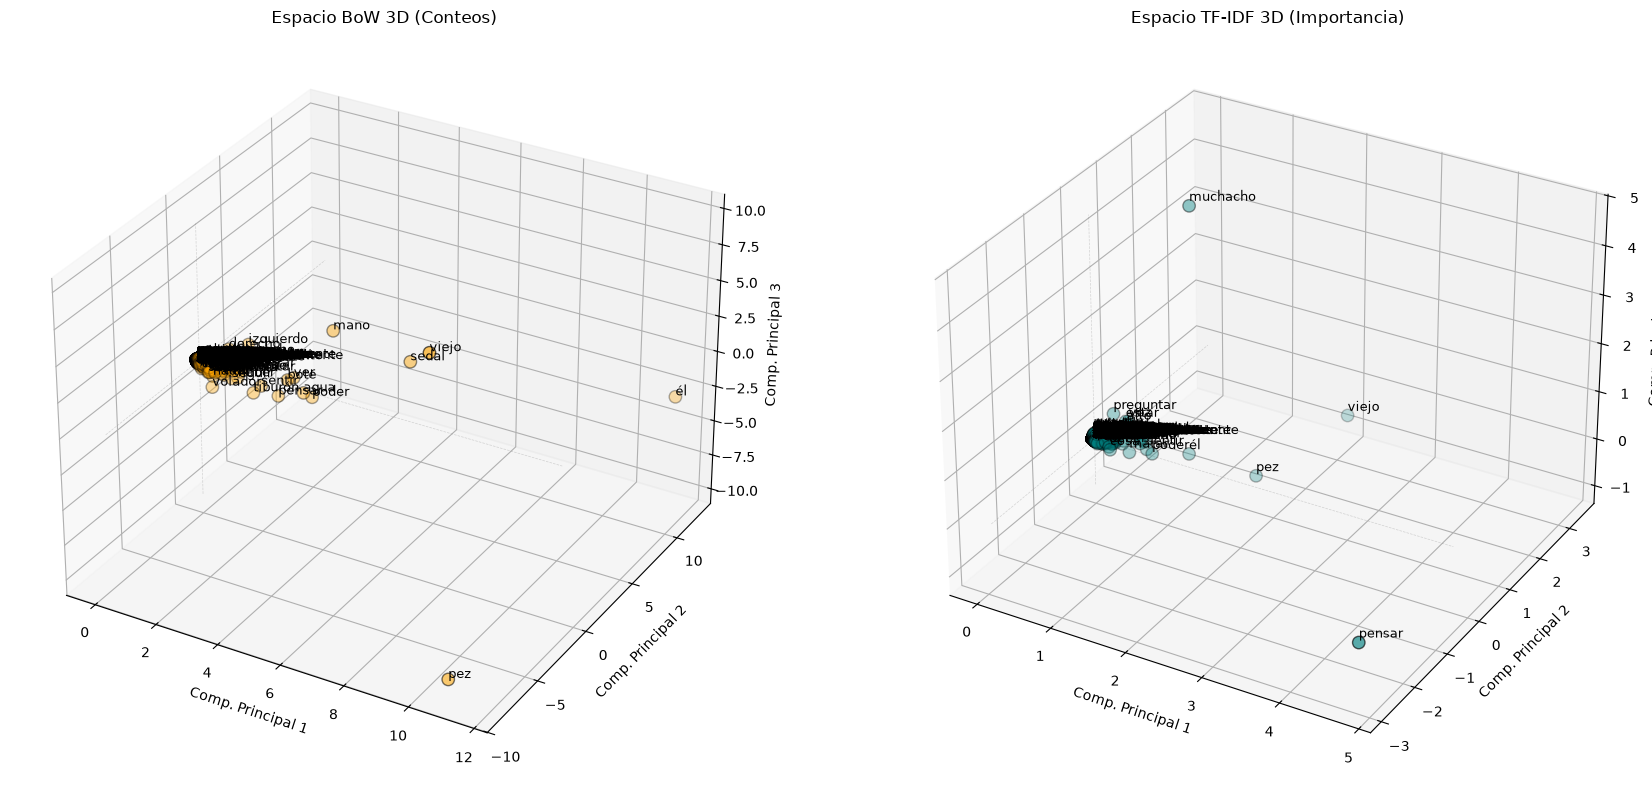

In [12]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # Import necesario para 3D
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA
import numpy as np

# ---------------------------------------------------------
# FUNCIÓN AUXILIAR PARA GRAFICAR EN 3D
# ---------------------------------------------------------
def graficar_palabras_3d(ax, matriz, vocabulario, titulo, color_puntos):
    # 1. TRANSPONER: Filas = Palabras, Columnas = Contextos
    matriz_palabras = matriz.T
    
    # 2. PCA: Reducir a 3 DIMENSIONES
    pca = PCA(n_components=3)
    coords = pca.fit_transform(matriz_palabras.toarray())
    
    # Extraer coordenadas X, Y, Z
    x = coords[:, 0]
    y = coords[:, 1]
    z = coords[:, 2]
    
    # 3. GRAFICAR SCATTER 3D
    # Usamos profundidad visual (depthshade=True) para ayudar a la perspectiva
    ax.scatter(x, y, z, c=color_puntos, s=80, edgecolors='k', alpha=0.8, depthshade=True)
    
    # Etiquetar puntos
    for i, palabra in enumerate(vocabulario):
        # Agregamos un pequeño offset a Z para que el texto flote sobre el punto
        ax.text(x[i], y[i], z[i] + 0.1, palabra, fontsize=9)
        
    ax.set_title(titulo)
    ax.set_xlabel('Comp. Principal 1')
    ax.set_ylabel('Comp. Principal 2')
    ax.set_zlabel('Comp. Principal 3')
    
    # Líneas de referencia en el origen (0,0,0)
    ax.plot([0,0], [0,0], [z.min(), z.max()], c='grey', ls='--', lw=0.5, alpha=0.3)
    ax.plot([x.min(), x.max()], [0,0], [0,0], c='grey', ls='--', lw=0.5, alpha=0.3)
    ax.plot([0,0], [y.min(), y.max()], [0,0], c='grey', ls='--', lw=0.5, alpha=0.3)


# ---------------------------------------------------------
# CONFIGURACIÓN DE LA FIGURA 3D
# ---------------------------------------------------------
# Creamos una figura ancha para poner dos gráficos lado a lado
fig = plt.figure(figsize=(18, 8))

# --- A. BAG OF WORDS (Izquierda) ---
# subplot(filas, columnas, índice, proyección)
ax1 = fig.add_subplot(121, projection='3d')

bow_vectorizer = CountVectorizer()
X_bow = bow_vectorizer.fit_transform(corpus_lematizado)
vocab_bow = bow_vectorizer.get_feature_names_out()

graficar_palabras_3d(ax1, X_bow, vocab_bow, 
                     "Espacio BoW 3D (Conteos)", 
                     "orange")

# --- B. TF-IDF (Derecha) ---
ax2 = fig.add_subplot(122, projection='3d')

tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(corpus_lematizado)
vocab_tfidf = tfidf_vectorizer.get_feature_names_out()

graficar_palabras_3d(ax2, X_tfidf, vocab_tfidf, 
                     "Espacio TF-IDF 3D (Importancia)", 
                     "teal")

plt.tight_layout()
plt.show()